# Team + Seed Final Time Series Model

This notebook predicts tournament point differential using a final combination of:
- a team model (legacy + hot ARIMA signals)
- a seed signal built from average point differentials for each seed over prior years

### Stage 1:
$$m_{team} = \alpha \cdot (Legacy_{T1} - Legacy_{T2}) + (1 - \alpha) \cdot (Hot_{T1} - Hot_{T2})$$
where: 
- $Legacy_{T}$ measures the team's historical performance over past seasons
- $Hot_{T}$ measures the team's performance over this season's past games
- $\alpha$ is tuned in via grid search

### Stage 2:
$$m_{seed} = PD_{s1} - PD_{s2}$$
where:
- $PD_{s}$ measures average point differentials for seed $s$ over prior years
- $w_{team}$ is tuned via grid search

### Final calculation:
$$m_{final} = w_{team} \cdot m_{team} + (1 - w_{team}) \cdot m_{seed}$$

In [1]:
import re
import numpy as np
import pandas as pd
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

In [2]:
teams = pd.read_csv("Dataset/MTeams.csv")
spellings = pd.read_csv("Dataset/MTeamSpellings.csv")
seeds = pd.read_csv("Dataset/MNCAATourneySeeds.csv")
regular = pd.read_csv("Dataset/MRegularSeasonCompactResults.csv")
tournament = pd.read_csv("Dataset/Tournament Game Point Differentials.csv")

In [3]:
# 80/20 split
years = sorted(tournament["YEAR"].unique().tolist())
split_idx = round(len(years) * 0.8)
train_years = years[:split_idx]
test_years = years[split_idx:]
print("train:", train_years)
print("test: ", test_years)

train: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022]
test:  [2023, 2024, 2025]


In [4]:
def normalize_name(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

name_to_id = {}
for r in teams.itertuples(index=False):
    name_to_id[normalize_name(r.TeamName)] = int(r.TeamID)
for r in spellings.itertuples(index=False):
    name_to_id[normalize_name(r.TeamNameSpelling)] = int(r.TeamID)

In [5]:
seeds = seeds.copy()
seeds["YEAR"] = seeds["Season"] # rename to match across datasets
seeds["SEED_NUM"] = pd.to_numeric(seeds["Seed"].str.extract(r"(\d+)")[0]) # get seed number
seeds["SEED_RANGE"] = pd.cut(seeds["SEED_NUM"], bins=[0, 2, 5, 8, 11, 16], labels=["B-1-2", "B-3-5", "B-6-8", "B-9-11", "B-12-16"])
seed_lookup = seeds[["YEAR", "TeamID", "SEED_NUM", "SEED_RANGE"]].copy()

team1_seed = seed_lookup.rename(columns={"TeamID": "TEAM1_ID", "SEED_NUM": "TEAM1_SEED", "SEED_RANGE": "TEAM1_SEED_RANGE"})
team2_seed = seed_lookup.rename(columns={"TeamID": "TEAM2_ID", "SEED_NUM": "TEAM2_SEED", "SEED_RANGE": "TEAM2_SEED_RANGE"})

# combine team 1 and team 2 seed info for matchups
tournament["TEAM1_ID"] = tournament["TEAM1"].map(lambda x: name_to_id.get(normalize_name(x)))
tournament["TEAM2_ID"] = tournament["TEAM2"].map(lambda x: name_to_id.get(normalize_name(x)))
tournament = tournament.merge(team1_seed, on=["YEAR", "TEAM1_ID"])
tournament = tournament.merge(team2_seed, on=["YEAR", "TEAM2_ID"])

In [6]:
# regular season game margins by team
team_game_rows = []
for row in regular.itertuples(index=False):
    margin = row.WScore - row.LScore
    team_game_rows.append({"YEAR": row.Season, "DAYNUM": row.DayNum, "TEAM_ID": row.WTeamID, "MARGIN": margin, "OPPONENT_ID": row.LTeamID})
    team_game_rows.append({"YEAR": row.Season, "DAYNUM": row.DayNum, "TEAM_ID": row.LTeamID, "MARGIN": -margin, "OPPONENT_ID": row.WTeamID})

team_games = pd.DataFrame(team_game_rows).sort_values(["TEAM_ID", "YEAR", "DAYNUM"]).reset_index(drop=True)

# regular season game margins by seed
seed_game_rows = []
for row in regular.itertuples(index=False):
    margin = row.WScore - row.LScore
    winner_seed = seed_lookup[(seed_lookup["YEAR"] == row.Season) & (seed_lookup["TeamID"] == row.WTeamID)]
    loser_seed = seed_lookup[(seed_lookup["YEAR"] == row.Season) & (seed_lookup["TeamID"] == row.LTeamID)]

    if len(winner_seed) > 0:
        seed_game_rows.append({"YEAR": row.Season, "SEED_NUM": int(winner_seed.iloc[0]["SEED_NUM"]), "MARGIN": margin})
    if len(loser_seed) > 0:
        seed_game_rows.append({"YEAR": row.Season, "SEED_NUM": int(loser_seed.iloc[0]["SEED_NUM"]), "MARGIN": -margin})

seed_games = pd.DataFrame(seed_game_rows).sort_values(["SEED_NUM", "YEAR"]).reset_index(drop=True)

print("team_games:")
print(team_games.head())
print("\nseed_games:")
print(seed_games.head())

team_games:
   YEAR  DAYNUM  TEAM_ID  MARGIN  OPPONENT_ID
0  2014       5     1101     -19         1182
1  2014       7     1101     -28         1382
2  2014       9     1101     -23         1268
3  2014      13     1101     -62         1234
4  2014      15     1101      -7         1395

seed_games:
   YEAR  SEED_NUM  MARGIN
0  1985         1     -17
1  1985         1      46
2  1985         1      14
3  1985         1      27
4  1985         1      46


In [7]:
# tournament point margins -> by team and by seed
tourney_team_rows = []
tourney_seed_rows = []
for row in tournament.itertuples(index=False):
    tourney_team_rows.append({"YEAR": row.YEAR, "CURRENT_ROUND": row.CURRENT_ROUND, "TEAM_ID": row.TEAM1_ID, "MARGIN": float(row.POINT_DIFFERENTIAL)})
    tourney_team_rows.append({"YEAR": row.YEAR, "CURRENT_ROUND": row.CURRENT_ROUND, "TEAM_ID": row.TEAM2_ID, "MARGIN": -float(row.POINT_DIFFERENTIAL)})

    tourney_seed_rows.append({"YEAR": row.YEAR, "CURRENT_ROUND": row.CURRENT_ROUND, "SEED_NUM": int(row.TEAM1_SEED), "MARGIN": float(row.POINT_DIFFERENTIAL)})
    tourney_seed_rows.append({"YEAR": row.YEAR, "CURRENT_ROUND": row.CURRENT_ROUND, "SEED_NUM": int(row.TEAM2_SEED), "MARGIN": -float(row.POINT_DIFFERENTIAL)})

tourney_team_games = pd.DataFrame(tourney_team_rows)
tourney_seed_games = pd.DataFrame(tourney_seed_rows)
print(tourney_team_games.head())
print("\n", tourney_seed_games.head())

   YEAR  CURRENT_ROUND  TEAM_ID  MARGIN
0  2008              2   1272.0    -7.0
1  2008              2   1242.0     7.0
2  2008              4   1417.0   -15.0
3  2008              4   1272.0    15.0
4  2008              4   1242.0    18.0

    YEAR  CURRENT_ROUND  SEED_NUM  MARGIN
0  2008              2         1    -7.0
1  2008              2         1     7.0
2  2008              4         1   -15.0
3  2008              4         1    15.0
4  2008              4         1    18.0


In [8]:
def predict(series):
    x = series.values
    if len(x) == 0: # no data (nan handled in combine_margin)
        return np.nan
    if len(x) < 4: # not enough observations for arima, use mean
        return x.mean()
    model = auto_arima(x, d=None, information_criterion="aic", stepwise=True)
    return model.predict(1)[0]

In [9]:
def combine_margin(l1, l2, h1, h2, alpha):
    l_ok = pd.notna(l1) and pd.notna(l2)
    h_ok = pd.notna(h1) and pd.notna(h2)
    if l_ok and h_ok:
        return float(alpha * (l1 - l2) + (1 - alpha) * (h1 - h2))
    if l_ok: # no hot, rely on legacy
        return float(l1 - l2)
    if h_ok: # no legacy, rely on hot
        return float(h1 - h2)
    return 0 # neither legacy nor hot is available

In [10]:
# legacy series: using regular season & tournament games from prior years
def build_team_legacy_series(team_id, year, n_seasons=None):
    reg = team_games[(team_games["TEAM_ID"] == team_id) & (team_games["YEAR"] < year)][["YEAR", "MARGIN"]]
    tourn = tourney_team_games[(tourney_team_games["TEAM_ID"] == team_id) & (tourney_team_games["YEAR"] < year)][["YEAR", "MARGIN"]]
    s = pd.concat([reg, tourn]).groupby("YEAR")["MARGIN"].mean().sort_index()
    if n_seasons: s = s.iloc[-n_seasons:]
    return s

# hot series: using regular season & tournament games (before current round) from current year
def build_team_hot_series(team_id, year, current_round, n_games=None):
    reg = team_games[(team_games["TEAM_ID"] == team_id) & (team_games["YEAR"] == year)].sort_values("DAYNUM")["MARGIN"].reset_index(drop=True)
    prior_tourn = tourney_team_games[
        (tourney_team_games["TEAM_ID"] == team_id) &
        (tourney_team_games["YEAR"] == year) & # previous games from this year's tournament
        (tourney_team_games["CURRENT_ROUND"] > current_round)
    ].sort_values("CURRENT_ROUND", ascending=False)["MARGIN"].reset_index(drop=True)
    s = reg
    if prior_tourn.size > 0: s = pd.concat([s, prior_tourn])
    if n_games: s = s.iloc[-n_games:]
    return s

# pre-aggregate seed yearly margins
seed_yearly_avg = (
    pd.concat([
        seed_games[["SEED_NUM", "YEAR", "MARGIN"]],
        tourney_seed_games[["SEED_NUM", "YEAR", "MARGIN"]],
    ], ignore_index=True)
    .groupby(["SEED_NUM", "YEAR"], as_index=False)["MARGIN"]
    .mean()
)

# seed series: average point differentials for a seed over prior years
def build_seed_season_series(seed_num, year, n_seasons=None):
    s = seed_yearly_avg[
        (seed_yearly_avg["SEED_NUM"] == seed_num) &
        (seed_yearly_avg["YEAR"] < year)
    ].set_index("YEAR")["MARGIN"].sort_index()
    if n_seasons:
        s = s.iloc[-n_seasons:]
    return s

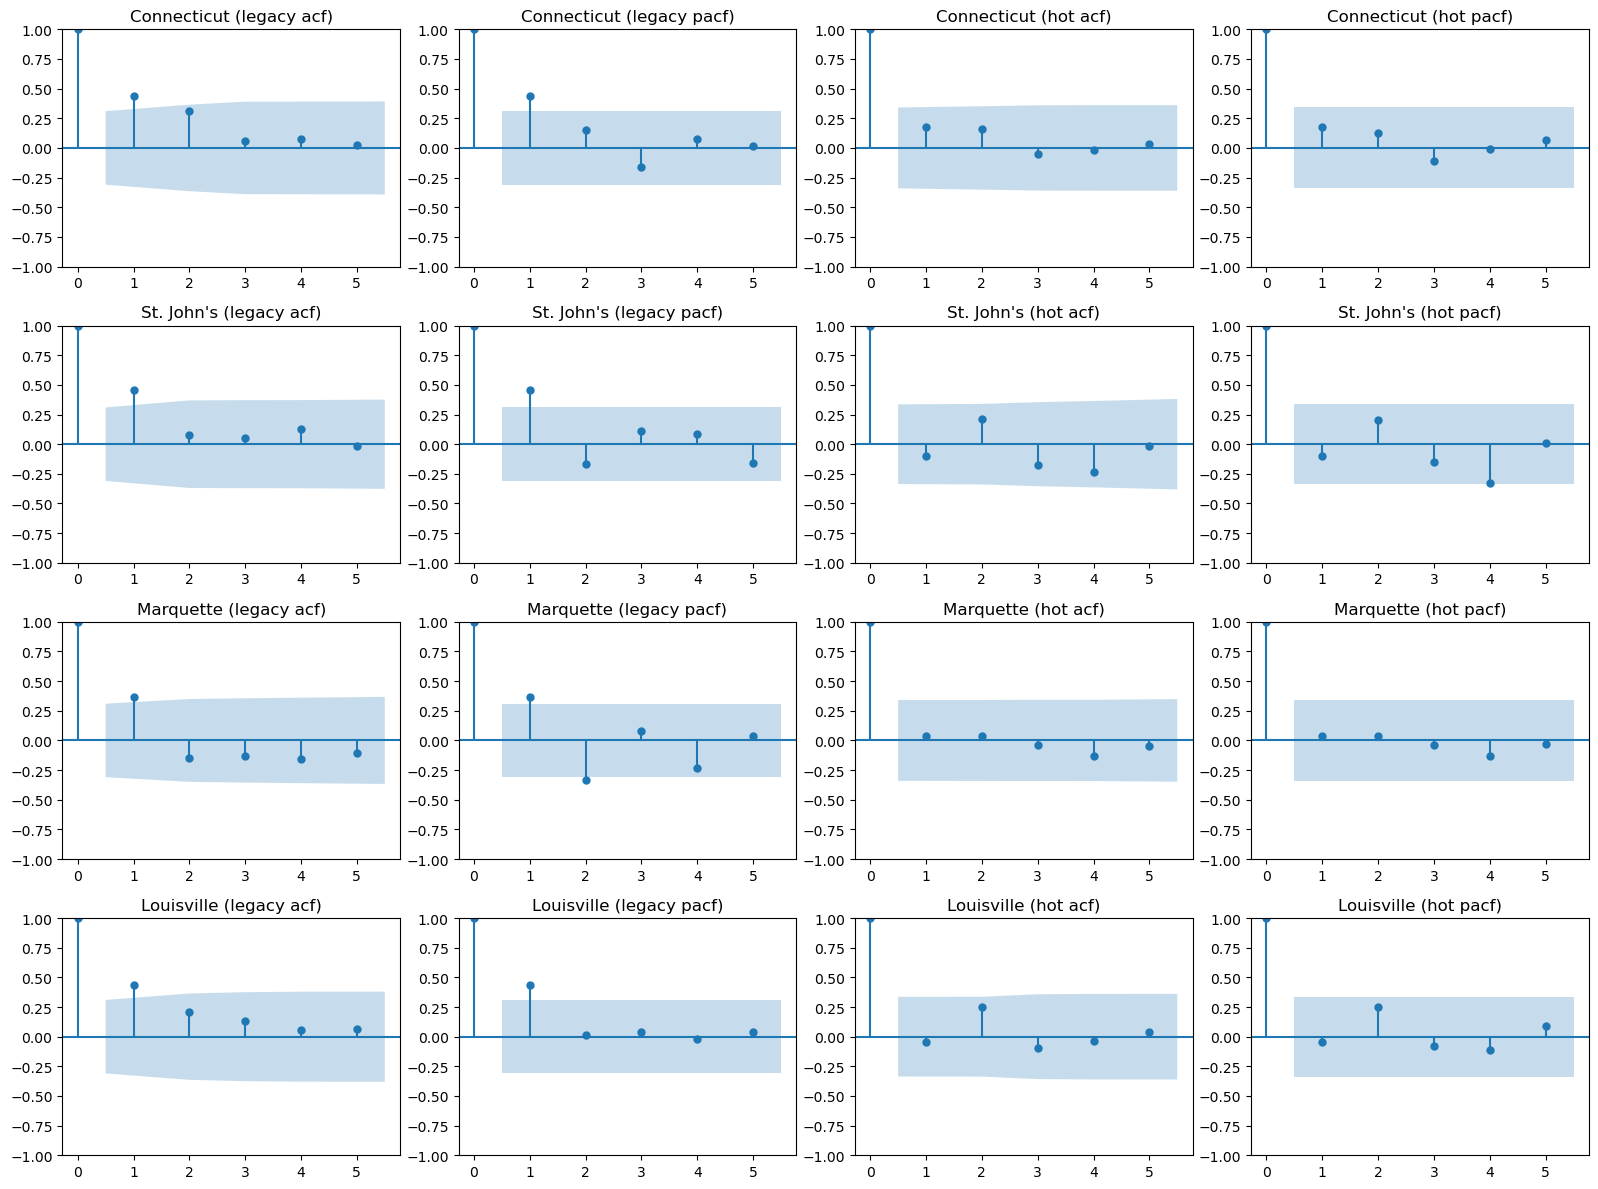

In [11]:
sample_teams = ["Connecticut", "St. John's", "Marquette", "Louisville"]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

for i, team_name in enumerate(sample_teams):
    team_id = name_to_id.get(normalize_name(team_name))
    if team_id is None:
        continue

    leg = build_team_legacy_series(team_id, 2025).values
    hot = build_team_hot_series(team_id, 2025, 999).values

    plot_acf(leg, lags=5, ax=axes[i, 0], title=f"{team_name} (legacy acf)")
    plot_pacf(leg, lags=5, ax=axes[i, 1], title=f"{team_name} (legacy pacf)")

    plot_acf(hot, lags=5, ax=axes[i, 2], title=f"{team_name} (hot acf)")
    plot_pacf(hot, lags=5, ax=axes[i, 3], title=f"{team_name} (hot pacf)")

plt.tight_layout()
plt.show()

In [12]:
alpha_grid = [0.1, 0.5, .9]
n_seasons_grid = [1, 3, 5]
n_games_grid = [1, 3, 5]

train_games = tournament[tournament["YEAR"].isin(train_years)].copy()

# stage 1: by team
tuning_results = []
for n_seasons in n_seasons_grid:
    l_scores = {} # avoid redundant predictions for the same year & team for different hyperparams
    for row in train_games.itertuples(index=False):
        for team_id in [row.TEAM1_ID, row.TEAM2_ID]:
            key = (row.YEAR, team_id)
            if key not in l_scores:
                l_scores[key] = predict(build_team_legacy_series(team_id, row.YEAR, n_seasons))

    for n_games in n_games_grid:
        h_scores = {} # avoid redundant predictions for the same round & year & team for different hyperparams
        for row in train_games.itertuples(index=False):
            for team_id in [row.TEAM1_ID, row.TEAM2_ID]:
                key = (row.YEAR, row.CURRENT_ROUND, team_id)
                if key not in h_scores:
                    h_scores[key] = predict(build_team_hot_series(team_id, row.YEAR, row.CURRENT_ROUND, n_games))

        for alpha in alpha_grid:
            errs = []
            for row in train_games.itertuples(index=False):
                # add new legacy predictions
                lk_1, lk_2 = (row.YEAR, row.TEAM1_ID), (row.YEAR, row.TEAM2_ID)
                hk_1 = (row.YEAR, row.CURRENT_ROUND, row.TEAM1_ID)
                hk_2 = (row.YEAR, row.CURRENT_ROUND, row.TEAM2_ID)
                pred = combine_margin(l_scores[lk_1], l_scores[lk_2], h_scores[hk_1], h_scores[hk_2], alpha)
                errs.append(abs(row.POINT_DIFFERENTIAL - pred))
            
            tuning_results.append({"n_seasons": n_seasons, "n_games": n_games, "alpha": alpha, "mae": float(np.mean(errs))})

tuning_df = pd.DataFrame(tuning_results)
best_row = tuning_df.loc[tuning_df["mae"].idxmin()]
best_n_seasons = int(best_row["n_seasons"])
best_n_games = int(best_row["n_games"])
best_alpha = float(best_row["alpha"])

print("best team-model config:")
print(best_row[["n_seasons", "n_games", "alpha", "mae"]])

best team-model config:
n_seasons     1.000000
n_games       3.000000
alpha         0.900000
mae          10.542264
Name: 5, dtype: float64


In [13]:
# stage 2: by seed
team_weight_grid = [0.5, 0.75, 1]
seed_scores = {}
legacy_scores = {}
hot_scores = {}

train_rows = list(train_games.itertuples(index=False))

for row in train_rows:
    for team_id in [row.TEAM1_ID, row.TEAM2_ID]:
        lk = (row.YEAR, team_id)
        if lk not in legacy_scores: # add new legacy predictions
            legacy_scores[lk] = predict(build_team_legacy_series(team_id, row.YEAR, best_n_seasons))
        hk = (row.YEAR, row.CURRENT_ROUND, team_id)
        if hk not in hot_scores: # add new hot predictions
            hot_scores[hk] = predict(build_team_hot_series(team_id, row.YEAR, row.CURRENT_ROUND, best_n_games))

    for seed in [int(row.TEAM1_SEED), int(row.TEAM2_SEED)]:
        lk = (row.YEAR, seed)
        if lk not in seed_scores: # add new seed predictions
            seed_scores[lk] = predict(build_seed_season_series(seed, row.YEAR, best_n_seasons))

actual = np.array([row.POINT_DIFFERENTIAL for row in train_rows])

team_preds = np.array([
    combine_margin(
        legacy_scores[(row.YEAR, row.TEAM1_ID)], legacy_scores[(row.YEAR, row.TEAM2_ID)],
        hot_scores[(row.YEAR, row.CURRENT_ROUND, row.TEAM1_ID)], hot_scores[(row.YEAR, row.CURRENT_ROUND, row.TEAM2_ID)],
        best_alpha,
    )
    for row in train_rows
])
seed_preds = np.array([
    seed_scores[(row.YEAR, int(row.TEAM1_SEED))] - seed_scores[(row.YEAR, int(row.TEAM2_SEED))]
    for row in train_rows
])

# combine team and seed predictions
final_results = []
for team_weight in team_weight_grid:
    pred = team_weight * team_preds + (1 - team_weight) * seed_preds
    mae = float(np.mean(np.abs(actual - pred)))
    final_results.append({"team_weight": team_weight, "mae": mae})

final_df = pd.DataFrame(final_results)
best_final_row = final_df.loc[final_df["mae"].idxmin()]
best_team_weight = float(best_final_row["team_weight"])

print("best team-vs-seed final weight:")
print(best_final_row[["team_weight", "mae"]])

best team-vs-seed final weight:
team_weight    0.500000
mae            9.999868
Name: 0, dtype: float64


In [14]:
# generate predictions for all tournament games using best hyperparameters
team_l_scores = {}
team_h_scores = {}
seed_scores = {}
pred_rows = []

for row in tournament.itertuples(index=False):
    for team_id in [row.TEAM1_ID, row.TEAM2_ID]:
        lk = (row.YEAR, team_id)
        if lk not in team_l_scores: # add new legacy predictions
            team_l_scores[lk] = predict(build_team_legacy_series(team_id, row.YEAR, best_n_seasons))
        hk = (row.YEAR, row.CURRENT_ROUND, team_id)
        if hk not in team_h_scores: # add new hot predictions
            team_h_scores[hk] = predict(build_team_hot_series(team_id, row.YEAR, row.CURRENT_ROUND, best_n_games))

    for seed_num in [int(row.TEAM1_SEED), int(row.TEAM2_SEED)]:
        lk = (row.YEAR, seed_num)
        if lk not in seed_scores: # add new seed predictions
            seed_scores[lk] = predict(build_seed_season_series(seed_num, row.YEAR, best_n_seasons))

    # all legacy and hot keys for this matchup
    t1_lk = (row.YEAR, row.TEAM1_ID)
    t2_lk = (row.YEAR, row.TEAM2_ID)
    t1_hk = (row.YEAR, row.CURRENT_ROUND, row.TEAM1_ID)
    t2_hk = (row.YEAR, row.CURRENT_ROUND, row.TEAM2_ID)
    s1_lk = (row.YEAR, int(row.TEAM1_SEED))
    s2_lk = (row.YEAR, int(row.TEAM2_SEED))

    team_pred_margin = combine_margin(
        team_l_scores[t1_lk], team_l_scores[t2_lk],
        team_h_scores[t1_hk], team_h_scores[t2_hk],
        best_alpha,
    )
    seed_pred_margin = seed_scores[s1_lk] - seed_scores[s2_lk]

    # final prediction combining team and seed margins
    pred_margin = best_team_weight * team_pred_margin + (1 - best_team_weight) * seed_pred_margin
    pred_rows.append({
        "YEAR": row.YEAR,
        "SPLIT": "train" if row.YEAR in train_years else "test",
        "CURRENT_ROUND": row.CURRENT_ROUND,
        "TEAM1": row.TEAM1, "TEAM2": row.TEAM2,
        "TEAM1_ID": row.TEAM1_ID, "TEAM2_ID": row.TEAM2_ID,
        "TEAM1_SEED": int(row.TEAM1_SEED), "TEAM2_SEED": int(row.TEAM2_SEED),
        "TEAM1_SEED_RANGE": row.TEAM1_SEED_RANGE, "TEAM2_SEED_RANGE": row.TEAM2_SEED_RANGE,
        "TEAM1_LEGACY": team_l_scores[t1_lk],
        "TEAM1_HOT": team_h_scores[t1_hk],
        "TEAM2_LEGACY": team_l_scores[t2_lk],
        "TEAM2_HOT": team_h_scores[t2_hk],
        "SEED1_LEGACY": seed_scores[s1_lk],
        "SEED2_LEGACY": seed_scores[s2_lk],
        "TEAM_MODEL_MARGIN": team_pred_margin,
        "SEED_MODEL_MARGIN": seed_pred_margin,
        "TEAM_WEIGHT": best_team_weight,
        "PRED_MARGIN": pred_margin,
        "POINT_DIFFERENTIAL": row.POINT_DIFFERENTIAL,
        "ABS_ERROR": abs(row.POINT_DIFFERENTIAL - pred_margin),
    })

preds = pd.DataFrame(pred_rows)
preds.head()

,YEAR,SPLIT,CURRENT_ROUND,TEAM1,TEAM2,TEAM1_ID,TEAM2_ID,TEAM1_SEED,TEAM2_SEED,TEAM1_SEED_RANGE,...,TEAM2_LEGACY,TEAM2_HOT,SEED1_LEGACY,SEED2_LEGACY,TEAM_MODEL_MARGIN,SEED_MODEL_MARGIN,TEAM_WEIGHT,PRED_MARGIN,POINT_DIFFERENTIAL,ABS_ERROR
0,2008,train,2,Memphis,Kansas,1272.0,1242,1,1,B-1-2,...,17.411765,11.666667,16.725926,16.725926,0.380927,0.000000,0.5,0.190463,-7,7.190463
1,2008,train,4,UCLA,Memphis,1417.0,1272,1,1,B-1-2,...,17.242424,13.000000,16.725926,16.725926,-5.524848,0.000000,0.5,-2.762424,-15,12.237576
2,2008,train,4,Kansas,North Carolina,1242.0,1314,1,1,B-1-2,...,18.147059,20.666667,16.725926,16.725926,-1.528431,0.000000,0.5,-0.764216,18,18.764216
3,2008,train,8,Xavier,UCLA,1462.0,1417,3,1,B-3-5,...,11.400000,5.000000,10.838462,16.725926,0.469167,-5.887464,0.5,-2.709149,-19,16.290851
4,2008,train,8,Texas,Memphis,1400.0,1272,2,1,B-1-2,...,17.242424,15.000000,13.325581,16.725926,-6.339394,-3.400345,0.5,-4.869869,-18,13.130131


In [15]:
recent = preds[preds["YEAR"] == 2025]

t1 = recent[["TEAM1", "TEAM1_LEGACY", "TEAM1_HOT"]].rename(columns={"TEAM1": "TEAM", "TEAM1_LEGACY": "LEGACY", "TEAM1_HOT": "HOT"})
t2 = recent[["TEAM2", "TEAM2_LEGACY", "TEAM2_HOT"]].rename(columns={"TEAM2": "TEAM", "TEAM2_LEGACY": "LEGACY", "TEAM2_HOT": "HOT"})
scores = pd.concat([t1, t2]).drop_duplicates("TEAM").set_index("TEAM")

n = 3
for col in ["LEGACY", "HOT"]:
    ranked = scores[col].dropna().sort_values(ascending=False)
    print(f"top {n} {col.lower()}:")
    print(ranked.head(n))
    print(f"\nbottom {n} {col.lower()}:")
    print(ranked.tail(n).sort_values())
    print()

top 3 legacy:
TEAM
Connecticut    18.000000
Houston        15.891892
Arizona        15.083333
Name: LEGACY, dtype: float64

bottom 3 legacy:
TEAM
Vanderbilt   -7.96875
Louisville   -7.06250
Michigan     -6.06250
Name: LEGACY, dtype: float64

top 3 hot:
TEAM
St. John's     20.666667
McNeese St.    19.666667
Duke           16.666667
Name: HOT, dtype: float64

bottom 3 hot:
TEAM
Vanderbilt   -10.333333
Marquette     -5.333333
Missouri      -3.333333
Name: HOT, dtype: float64



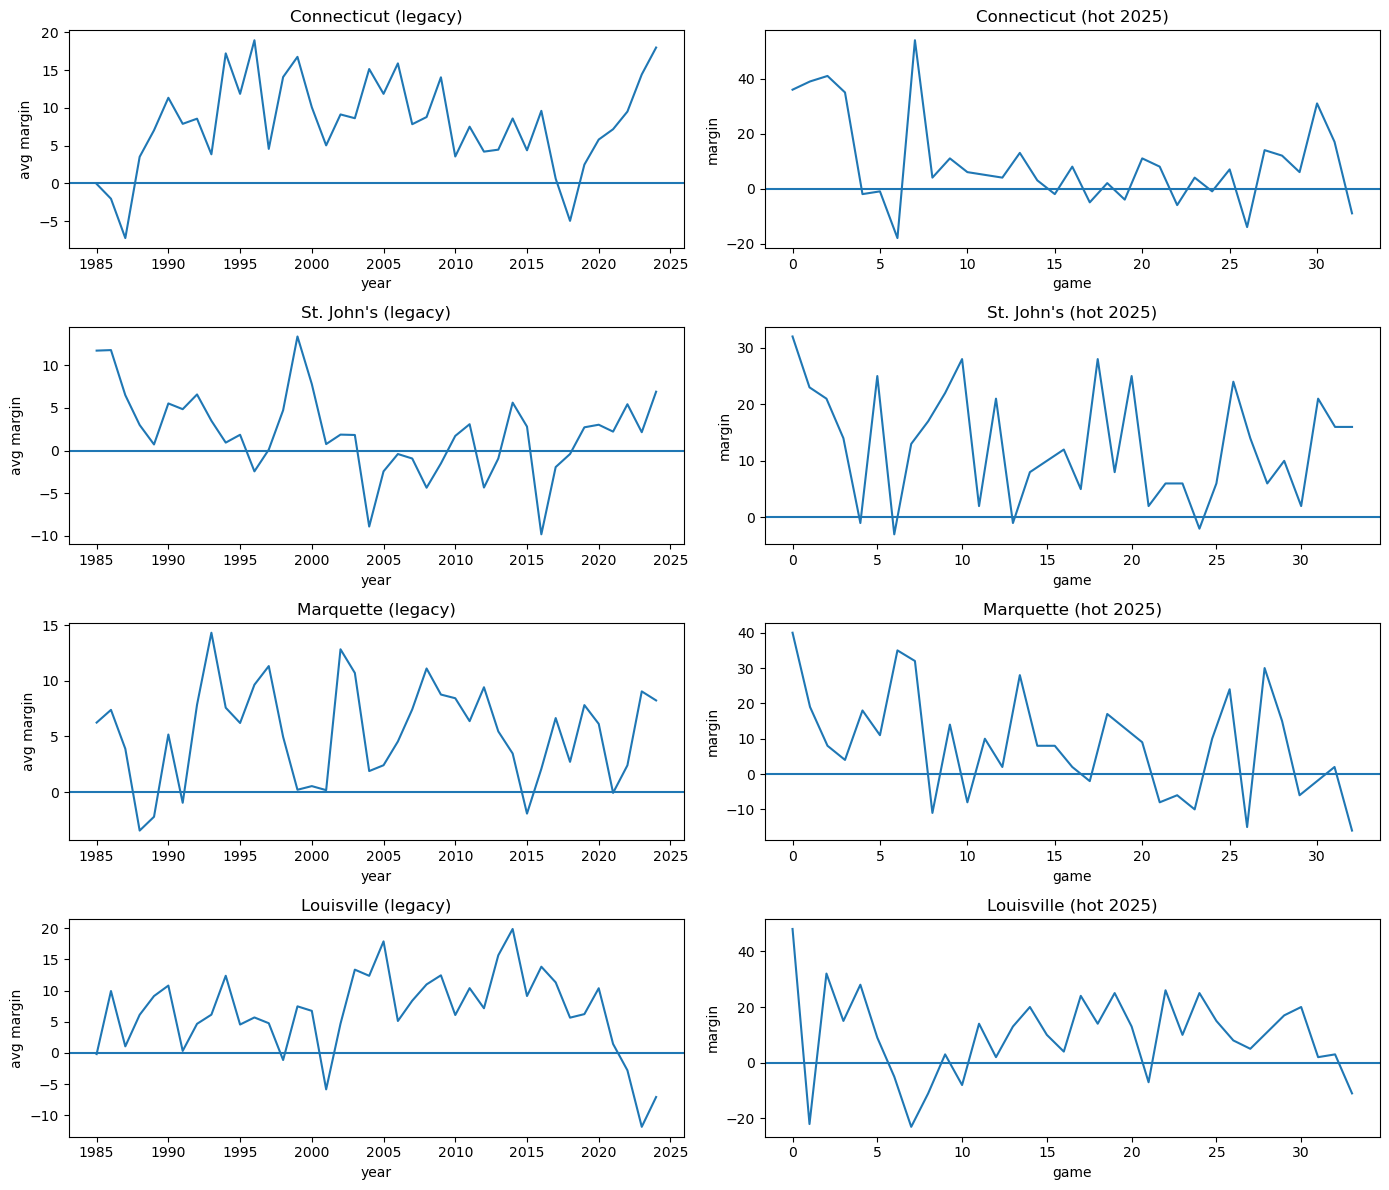

In [16]:
# plot legacy and hot series for top & bottom teams by legacy score
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for i, team_name in enumerate(sample_teams):
    team_id = name_to_id.get(normalize_name(team_name))
    # plot legacy series
    reg = team_games[(team_games["TEAM_ID"] == team_id) & (team_games["YEAR"] < 2025)][["YEAR", "MARGIN"]]
    tourn = tourney_team_games[(tourney_team_games["TEAM_ID"] == team_id) & (tourney_team_games["YEAR"] < 2025)][["YEAR", "MARGIN"]]
    leg = pd.concat([reg, tourn]).groupby("YEAR")["MARGIN"].mean()
    axes[i, 0].plot(leg.index, leg.values)
    axes[i, 0].axhline(0)
    axes[i, 0].set_title(f"{team_name} (legacy)")
    axes[i, 0].set_xlabel("year")
    axes[i, 0].set_ylabel("avg margin")
    # plot hot series
    hot = team_games[(team_games["TEAM_ID"] == team_id) & (team_games["YEAR"] == 2025)].sort_values("DAYNUM")["MARGIN"].values
    axes[i, 1].plot(range(len(hot)), hot)
    axes[i, 1].axhline(0)
    axes[i, 1].set_title(f"{team_name} (hot 2025)")
    axes[i, 1].set_xlabel("game")
    axes[i, 1].set_ylabel("margin")

plt.tight_layout()
plt.show()

In [17]:
train_mae = preds.loc[preds["SPLIT"] == "train", "ABS_ERROR"].mean()
test_mae = preds.loc[preds["SPLIT"] == "test", "ABS_ERROR"].mean()

print("overall margin mae:")
print({"train": train_mae, "test": test_mae})

print("\nmae by year:")
yearly_results = (
    preds.groupby(["SPLIT", "YEAR"], as_index=False)
    .agg(N_GAMES=("YEAR", "size"), MARGIN_MAE=("ABS_ERROR", "mean"))
    .sort_values("YEAR")
)
print(yearly_results.to_string(index=False))

overall margin mae:
{'train': np.float64(9.999868022245408), 'test': np.float64(10.985725874355955)}

mae by year:
SPLIT  YEAR  N_GAMES  MARGIN_MAE
train  2008       62   10.619593
train  2009       63    9.974341
train  2010       63    8.938957
train  2011       63   10.232406
train  2012       63    8.409628
train  2013       63   12.011628
train  2014       63    8.854243
train  2015       63    8.626352
train  2016       62    9.884344
train  2017       63    9.233482
train  2018       63    9.820910
train  2019       63   10.342058
train  2021       62   10.984625
train  2022       63   12.089221
 test  2023       62   10.535259
 test  2024       63   12.096653
 test  2025       63   10.318115


In [18]:
preds.to_csv("Predictions/timeseries.csv", index=False)